In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.6/351.2 MB 14.4 MB/s eta 0:00:25
   ---------------------------------------- 3.9/351.2 MB 9.9 MB/s eta 0:00:36
    --------------------------------------- 5.2/351.2 MB 8.5 MB/s eta 0:00:41
    --------------------------------------- 6.6/351.2 MB 7.8 MB/s eta 0:00:45
    --------------------------------------- 7.9/351.2 MB 7.5 MB/s eta 0:00:46
   - -------------------------------------- 8.9/351.2 MB 7.3 MB/s eta 0:00:48
   - --------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Pratham\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.21.0


In [11]:
# Load Boston Housing Dataset from local CSV file
# The file is space-separated with NO header row
# Columns: CRIM, ZN, INDUS, CHAS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT, MEDV

col_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
             'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

df = pd.read_csv('housing.csv', sep=r'\s+', header=None, names=col_names)

print('Shape of dataset:', df.shape)
print('\nFirst 5 rows:')
df.head()


Shape of dataset: (506, 14)

First 5 rows:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [12]:
# Basic info
print("Dataset Info:")
print(df.info())
print("\nStatistics:")
df.describe()


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None

Statistics:


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [13]:
# Check for missing values
print('Missing values:', df.isnull().sum().sum())

# Target column is 'MEDV' (Median value of homes in $1000s)
print('\nTarget column (MEDV) - House Price range:')
print('Min:', df['MEDV'].min(), '| Max:', df['MEDV'].max())


Missing values: 0

Target column (MEDV) - House Price range:
Min: 5.0 | Max: 50.0


In [14]:
# Separate features and target
X = df.drop('MEDV', axis=1).values   # 13 input features
y = df['MEDV'].values                 # Target: house price

print('Features shape:', X.shape)
print('Target shape  :', y.shape)
print('Feature names :', df.drop('MEDV', axis=1).columns.tolist())

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('\nTrain size:', X_train.shape[0])
print('Test size :', X_test.shape[0])


Features shape: (506, 13)
Target shape  : (506,)
Feature names : ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

Train size: 404
Test size : 102


In [15]:
# Normalize / Scale the data (important for neural networks)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data scaled successfully!")
print("Mean of train data:", X_train.mean().round(4))


Data scaled successfully!
Mean of train data: 0.0


In [16]:
# Build model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Hidden Layer 1
    keras.layers.Dense(32, activation='relu'),                                    # Hidden Layer 2
    keras.layers.Dense(16, activation='relu'),                                    # Hidden Layer 3
    keras.layers.Dense(1)                                                          # Output layer (1 value = price)
])

# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Show model summary
model.summary()


C:\Users\Pratham\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,521 (13.75 KB)

 Trainable params: 3,521 (13.75 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nTraining complete!")


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 605.2779 - mae: 22.7534 - val_loss: 582.7172 - val_mae: 22.6362
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 577.6528 - mae: 22.1582 - val_loss: 549.6606 - val_mae: 21.9437
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 538.1556 - mae: 21.2943 - val_loss: 498.9640 - val_mae: 20.8540
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 477.2525 - mae: 19.8881 - val_loss: 420.6556 - val_mae: 19.0256
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 383.0739 - mae: 17.5245 - val_loss: 309.2263 - val_mae: 16.0211
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 262.9840 - mae: 13.8699 - val_loss: 176.4087 - val_mae: 11.5327
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 142.9131 - mae: 9.7948 - val_loss: 85.5310 - val_mae: 6.8777
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 85.2833 - mae: 7.4601 - val_loss: 55.1145 - val_mae: 5.1375
Epoch 9/100
12/

In [18]:
# Predict on test data
y_pred = model.predict(X_test).flatten()

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"  MSE  (Mean Squared Error) : {mse:.2f}")
print(f"  RMSE (Root MSE)           : {rmse:.2f}")
print(f"  R2 Score                  : {r2:.4f}")
print(f"\n  (R2 closer to 1 = better model)")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
Model Performance:
  MSE  (Mean Squared Error) : 12.19
  RMSE (Root MSE)           : 3.49
  R2 Score                  : 0.8337

  (R2 closer to 1 = better model)


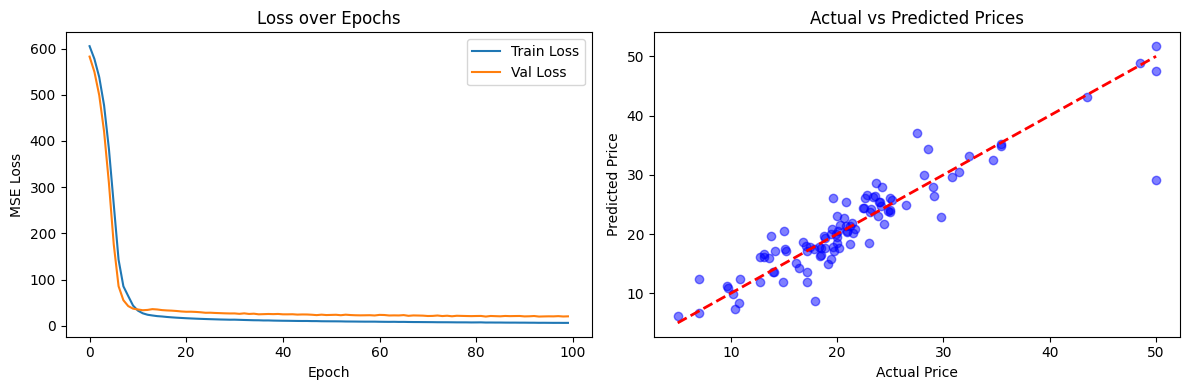

In [19]:
# Plot 1: Training Loss vs Validation Loss
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()

# Plot 2: Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted Prices')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')

plt.tight_layout()
plt.show()


## Conclusion

- We built a **Deep Neural Network** with 3 hidden layers to predict Boston house prices.
- The model uses **ReLU** activation and **Adam** optimizer.
- **MSE** measures prediction error — lower is better.
- **R2 Score** shows how well the model fits the data — closer to 1 is better.
